In [1]:
import time
import numpy as np
import gymnasium as gym

def test_env(env):
    env.reset()
    secs = []
    for _ in range(1000):
        start = time.perf_counter()
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        #env.render()
        if terminated or truncated:
            env.reset()
        end = time.perf_counter()
        #print(f"Step took {end - start:.4f} seconds, reward: {reward}, action: {action}")
        secs.append(end - start)
    print(f"Average step time: {np.mean(secs):.4f}+-{np.std(secs)} seconds")
    env.close()

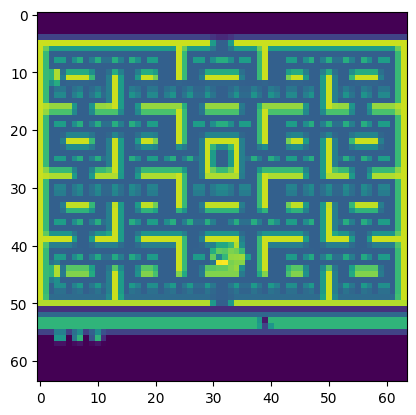

In [2]:
import ale_py
from utils import PreprocessFrame

preprocess = PreprocessFrame(True, (64,64))
env = env = gym.make("ALE/Pacman-v5")
state, _ = env.reset()
for _ in range(100):
    state, *_ = env.step(0)
state = preprocess(state)

import matplotlib.pyplot as plt
plt.figure()
plt.imshow(state)
plt.show()

In [3]:
#env = gym.make("CarRacing-v3", continuous = True, render_mode="human")
#test_env(env)

env = gym.make("CarRacing-v3", continuous = False, render_mode="human")
test_env(env)

'''
import ale_py
env = gym.make("ALE/Pong-v5")
test_env(env)

env = gym.make("ALE/Pacman-v5")
test_env(env)
'''

c:\Users\hss19\anaconda3\envs\ml-torch\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Average step time: 0.0267+-0.004799784301149112 seconds


'\nimport ale_py\nenv = gym.make("ALE/Pong-v5")\ntest_env(env)\n\nenv = gym.make("ALE/Pacman-v5")\ntest_env(env)\n'

In [ ]:
import pygame

def play_env(env):
    pygame.init()
    screen = pygame.display.set_mode((400, 300))
    pygame.display.set_caption("Playing")

    # Action meanings for Pong
    # 0 = NOOP
    # 1 = FIRE
    # 2 = UP
    # 3 = DOWN
    # 4 = RIGHT
    # 5 = LEFT

    action = 0  # default action

    obs, info = env.reset()
    # Game loop
    while True:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                env.close()
                pygame.quit()
                return 0
            elif event.type == pygame.KEYDOWN:
                if event.key == pygame.K_UP:
                    action = 2
                elif event.key == pygame.K_DOWN:
                    action = 3
                elif event.key == pygame.K_SPACE:
                    action = 1
                elif event.key == pygame.K_ESCAPE:
                    env.close()
                    pygame.quit()
                    sys.exit()
            elif event.type == pygame.KEYUP:
                action = 0  # Stop moving when key is released

        # Step environment
        obs, reward, terminated, truncated, info = env.step(action)

        if terminated or truncated:
            obs, info = env.reset()

        pygame.time.delay(30)

env = gym.make("ALE/Pacman-v5", render_mode='human')
play_env(env)

KeyboardInterrupt: 

: 